# 3.0.6 优化：怎样让模型稳定地下山

> 3.0 基础课程：先直觉，再符号，再数字代入，再用代码和图形核对。

## Goal

区分训练目标与评测指标，理解 GD/SGD/mini-batch、学习率、Momentum/Adam、凸与非凸、初始化、L1/L2、早停、梯度裁剪和多任务梯度冲突。

## Setup 与数据边界

本课不加载用户行为数据。代码中的小数组都是带标签的 **数学教学对象**，只用于验证公式，绝不冒充交互、曝光、标签或行为序列。

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
TEACHING_OBJECTS_ONLY = True
print({"project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "kind": "curriculum", "teaching_objects_only": True})

from matplotlib import font_manager

# Matplotlib 默认的 DejaVu Sans 不包含中文字形。优先选择容器中的 Noto CJK
# （镜像已安装 fonts-noto-cjk），其次是宿主机常见中文字体；从字体根源解决，
# 而不是用 warnings.filterwarnings 掩盖 missing glyph 警告。
cjk_candidates = ('Noto Sans CJK SC', 'Noto Sans CJK JP', 'PingFang SC', 'Hiragino Sans GB',
                  'Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'Songti SC')
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
cjk_font = next((name for name in cjk_candidates if name in installed_fonts), None)
if cjk_font:
    plt.rcParams['font.sans-serif'] = [cjk_font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('图表字体:', cjk_font or '未找到中文字体（请安装 fonts-noto-cjk）')

{'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'kind': 'curriculum', 'teaching_objects_only': True}
图表字体: Hiragino Sans GB


## 学习路径

先画出目标函数地形；用梯度决定方向、学习率决定步长；再理解随机小批次的噪声，最后加入正则化、早停和梯度稳定措施。

## 符号表

| 符号 | 含义 |
|---|---|
| $\theta$ | 模型全部可学习参数 |
| $L(\theta)$ | 训练目标/损失 |
| $\nabla L$ | 当前点的梯度 |
| $\eta$ | 学习率 |
| $\lambda$ | 正则强度 |
| $B$ | mini-batch 样本数 |

> 本课曲线、参数和梯度均为数学教学对象，不是实验效果声明。

<a id="sgd"></a>
## 1. 目标、指标、GD、SGD 与 mini-batch

目标是训练时直接最小化的数，如交叉熵；指标是最终关心的评价，如 Recall@K，它可能不可导。全批 GD 用全部数据求梯度，SGD 用一个样本，mini-batch 用一小批：速度、内存与噪声之间折中。

### 数字代入 1：一次梯度下降

$L(w)=(w-3)^2$，在 $w=0$ 的梯度 $2(w-3)=-6$。学习率 $\eta=0.1$ 时，$w\leftarrow0-0.1(-6)=0.6$；损失从 9 降到 $(0.6-3)^2=5.76$。

<a id="learning-rate"></a>
## 2. 学习率、Momentum、Adam、凸与非凸

学习率太小走得慢，太大会跨过谷底甚至发散。Momentum 像带惯性的球，累积一致方向；Adam 再按每个参数近期梯度平方调整步长。凸函数像单碗，任意局部最低也是全局最低；深度网络通常非凸，更像有坡、鞍点和平坦区的山地，因此初始化和随机性重要。

### 数字代入 2：大步跨谷

仍取 $w=0$、梯度 $-6$。若 $\eta=1.1$，一步到 $6.6$，损失变 $12.96$，反而比 9 大。更新公式没错，错的是步长与曲率不匹配。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


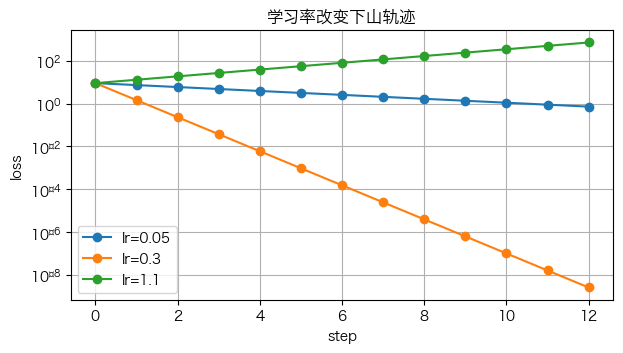

In [2]:
# Demo 1：同一教学目标，不同学习率的轨迹。
def path(lr, steps=12):
    w=0.; out=[w]
    for _ in range(steps):
        w -= lr*2*(w-3); out.append(w)
    return np.array(out)
fig, ax=plt.subplots(figsize=(7,3.5))
for lr in [.05,.3,1.1]:
    p=path(lr); ax.plot((p-3)**2,"o-",label=f"lr={lr}")
ax.set_yscale("log"); ax.set(xlabel="step",ylabel="loss",title="学习率改变下山轨迹"); ax.legend(); ax.grid(); plt.show()

<a id="regularization"></a>
## 3. L1/L2、过拟合与早停

训练误差低而验证误差升高叫过拟合。L2 在目标中加入 $\lambda\sum_jw_j^2$，平滑地压小权重；L1 加 $\lambda\sum_j|w_j|$，更容易把部分权重推到 0。早停在验证指标不再改善时保存最佳点，不能根据测试集早停。

### 数字代入 3：L2 代价

$w=[3,4]$，原损失为 2，$\lambda=0.1$。L2 项为 $0.1(3^2+4^2)=2.5$，总目标 $4.5$。若权重减半，L2 项降为 $0.625$，但数据误差可能上升；训练在两者间权衡。

梯度爆炸指梯度过大，裁剪可令 $g\leftarrow g\min(1,c/\|g\|)$；梯度消失则需检查激活、初始化、归一化和网络路径，单靠裁剪无效。

<a id="gradient-conflict"></a>
## 4. 多任务梯度冲突

多任务共享参数时，各任务梯度可能同向也可能冲突。若点击梯度 $g_1=[1,0]$、长播梯度 $g_2=[-0.8,0.2]$，点积为 $-0.8<0$，说明对一个任务下降的方向可能伤害另一个。任务加权、专家分离或梯度处理都在管理这类跷跷板。

### 数字代入 4：梯度裁剪

$g=[6,8]$ 的长度是 10；阈值 $c=5$ 时乘 $5/10$，得到 $[3,4]$，方向不变、长度变 5。

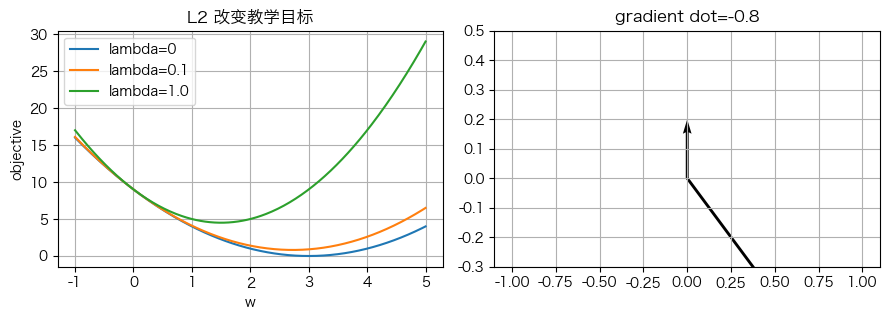

clipped [3. 4.]


In [3]:
# Demo 2：L2 改变最优点；并画出两个冲突梯度。
xs=np.linspace(-1,5,300); data_loss=(xs-3)**2
fig,ax=plt.subplots(1,2,figsize=(9,3.3))
for lam in [0,.1,1.]: ax[0].plot(xs,data_loss+lam*xs**2,label=f"lambda={lam}")
ax[0].set(title="L2 改变教学目标",xlabel="w",ylabel="objective"); ax[0].legend(); ax[0].grid()
g1=np.array([1.,0.]); g2=np.array([-.8,.2])
ax[1].quiver([0,0],[0,0],[*g1],[*g2],angles="xy",scale_units="xy",scale=1)
ax[1].set(xlim=(-1.1,1.1),ylim=(-.3,.5),title=f"gradient dot={g1@g2:.1f}"); ax[1].grid()
plt.tight_layout(); plt.show()
g=np.array([6.,8.]); clipped=g*min(1,5/np.linalg.norm(g)); print("clipped",clipped)

## 常见误区

- 损失越低，业务指标一定越好：训练代理目标与最终指标不同。
- Adam 不需要学习率：它自适应缩放，但全局步长仍关键。
- 正则越强越好：过强会欠拟合。
- 多任务总损失下降就都变好：某个任务可能被牺牲。

## 算法回链

- [BiasMF：SGD 与 L2](/notebooks/3_1_2_matrix_factorization)
- [DeepFM：mini-batch 与共享参数](/notebooks/3_3_1_deepfm)
- [MMoE：gate 与任务冲突](/notebooks/3_4_1_mmoe)
- [PLE：共享/专属专家缓解负迁移](/notebooks/3_4_2_ple)
- [HSTU：长序列训练稳定性](/notebooks/4_3_dlrm_hstu_practice)

## Checks

1. 为什么测试指标不能用来早停？
2. 学习率太大时损失为何可能来回变大？
3. 两任务梯度点积为负说明什么？

In [4]:
assert path(.1)[-1] > 0 and (path(.1)[-1]-3)**2 < 9
assert np.isclose(np.linalg.norm(clipped),5)
assert g1@g2 < 0
assert np.isclose(2 + .1*(3**2+4**2),4.5)
print("PASS：学习率、L2、裁剪与梯度冲突检查通过。")

PASS：学习率、L2、裁剪与梯度冲突检查通过。


## Next Steps

继续进入 3.0.7 数据与实验基础，把数据切分、张量化、训练、推理和测试连接成完整工程管线。